In [ ]:
import polars as pl
from pathlib import Path
from glob import glob

# Point to the data/ directory at repo root (download S3 data there)
DATA_DIR = Path('../data')

In [3]:
def create_adaptive_timeline_plot_optimized(df: pl.DataFrame, figsize=(12, 8), dpi=100, 
                                color_map=None, event_order=None, 
                                align_on=None, sort_by=None, group_by=None, 
                                ax=None, fontsize=None, use_calendar_years=False,
                                show_progress=True, show_legend=True, legend_position='right'):
    """
    Optimized version of create_adaptive_timeline_plot for longitudinal data with progress tracking.
    
    Parameters:
    -----------
    df : polars.DataFrame
        DataFrame containing the timeline data with required columns:
        'id', 'state', 'start_date', 'end_date'
    show_progress : bool, optional
        If True, displays progress information during calculation
    show_legend : bool, optional
        If True, displays a legend with state colors (default: True)
    legend_position : str, optional
        Position of legend: 'right', 'left', 'top', 'bottom' (default: 'right')
    ... (all other parameters same as original)
        
    Returns:
    --------
    matplotlib.axes.Axes or tuple
        Either the axes object or (figure, axes) if ax was None
    """
    import matplotlib.pyplot as plt
    from matplotlib.collections import PolyCollection, LineCollection
    from matplotlib.patches import Rectangle
    from datetime import datetime
    import numpy as np
    import random
    import polars as pl
    from tqdm.auto import tqdm
    import time
    
    def progress_print(message, show=show_progress):
        """Print progress message if show_progress is True"""
        if show:
            print(f"🚀 {message}")
    
    start_time = time.time()
    progress_print("Starting optimized timeline plot creation...")
    
    # Ensure required columns are present
    required_cols = ['id', 'state', 'start_date', 'end_date']
    if not all(col in df.columns for col in required_cols):
        raise ValueError(f"DataFrame must contain columns: {', '.join(required_cols)}")

    progress_print(f"Input data: {len(df)} rows, {df['id'].n_unique()} unique patients")

    # Filter out IDs without the align_on state if specified
    if align_on:
        progress_print(f"Filtering data to patients with '{align_on}' state...")
        aligned_ids = df.filter(pl.col('state') == align_on)['id'].unique().to_list()
        original_count = df['id'].n_unique()
        df = df.filter(pl.col('id').is_in(aligned_ids))
        filtered_count = df['id'].n_unique()
        progress_print(f"Filtered from {original_count} to {filtered_count} patients")

    # 1: Pre-compute all patient statistics in one pass
    progress_print("Computing patient statistics (optimized)...")
    grouped = df.group_by('id').agg([
        pl.col('start_date').min().alias('min_date'),
        pl.col('start_date').max().alias('max_date'),
        pl.col('state').unique().alias('states_list')  # Get all states for each patient
    ])

    # 2: Create patient ID to index mapping for O(1) lookups
    patient_to_idx = {patient_id: idx for idx, patient_id in enumerate(grouped['id'].to_list())}
    progress_print(f"Created patient index mapping for {len(patient_to_idx)} patients")

    # Handle group_by parameter with
    if group_by:
        progress_print(f"Processing group_by parameter: {group_by}")
        group_states = [group_by] if isinstance(group_by, str) else group_by
        
        # 3: Vectorized group indicator creation
        all_patient_ids = set(grouped['id'].to_list())
        group_indicators_data = {'id': grouped['id']}
        
        for state in group_states:
            state_patient_ids = set(df.filter(pl.col('state') == state)['id'].unique().to_list())
            group_indicators_data[f'has_{state}'] = [
                patient_id in state_patient_ids for patient_id in grouped['id']
            ]
        
        group_df = pl.DataFrame(group_indicators_data)
        grouped = grouped.join(group_df, on='id')

    # Reference date for calculations
    ref_date = grouped['min_date'].min()
    progress_print(f"Reference date: {ref_date}")
    
    # 4: Vectorized alignment and date calculations
    if align_on:
        progress_print(f"Aligning timelines to first occurrence of '{align_on}' (vectorized)...")
        align_dates = df.filter(pl.col('state') == align_on).group_by('id').agg(
            pl.col('start_date').min().alias('align_date')
        )
        grouped = grouped.join(align_dates, on='id', how='left')
        
        # Vectorized date calculations
        grouped = grouped.with_columns([
            (pl.col('min_date') - pl.col('align_date')).alias('start_days'),
            (pl.col('max_date') - pl.col('align_date')).alias('end_days')
        ])
    else:
        # Vectorized relative date calculations
        grouped = grouped.with_columns([
            (pl.col('min_date') - ref_date).alias('start_days'),
            (pl.col('max_date') - ref_date).alias('end_days')
        ])

    # Optimized sorting logic
    if sort_by:
        progress_print(f"Sorting patients by first occurrence of '{sort_by}' (optimized)...")
        sort_dates = df.filter(pl.col('state') == sort_by).group_by('id').agg(
            pl.col('start_date').min().alias('sort_date')
        )
        
        if align_on:
            grouped = grouped.join(sort_dates, on='id', how='left')
            grouped = grouped.with_columns(
                (pl.col('sort_date') - pl.col('align_date')).alias('relative_sort_days')
            )
            grouped = grouped.with_columns(
                pl.when(pl.col('sort_date').is_null())
                .then(float('inf'))
                .otherwise(pl.col('relative_sort_days'))
                .alias('final_sort_key')
            )
        else:
            earliest_dates = df.group_by('id').agg(pl.col('start_date').min().alias('earliest_date'))
            sorting_df = earliest_dates.join(sort_dates, on='id', how='left')
            sorting_df = sorting_df.with_columns(
                (pl.col('sort_date') - pl.col('earliest_date')).alias('sort_distance')
            )
            grouped = grouped.join(
                sorting_df.select(['id', 'sort_date', 'sort_distance']), 
                on='id', 
                how='left'
            )
            grouped = grouped.with_columns(
                pl.when(pl.col('sort_date').is_null())
                .then(float('inf'))
                .otherwise(pl.col('sort_distance'))
                .alias('final_sort_key')
            )
        
        if group_by:
            group_cols = [f'has_{state}' for state in group_states]
            sort_cols = group_cols + ['final_sort_key']
            grouped = grouped.sort(sort_cols, descending=[True] * len(group_cols) + [False])
        else:
            grouped = grouped.sort('final_sort_key')
    else:
        if group_by:
            group_cols = [f'has_{state}' for state in group_states]
            grouped = grouped.sort(group_cols, descending=[True] * len(group_cols))
        else:
            grouped = grouped.sort('start_days')

    # Update patient_to_idx mapping after sorting
    patient_to_idx = {patient_id: idx for idx, patient_id in enumerate(grouped['id'].to_list())}

    progress_print("Setting up matplotlib figure...")
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    # Default color map if not provided
    def generate_color():
        return "#"+''.join([random.choice('0123456789ABCDEF') for j in range(6)])

    # Event order
    if event_order is None:
        event_order = sorted(df['state'].unique().to_list())
    
    # Create color mapping and store for legend
    state_colors = {}
    for state in event_order:
        if color_map:
            state_colors[state] = color_map.get(state, generate_color())
        else:
            state_colors[state] = generate_color()
    
    progress_print(f"Processing {len(event_order)} event types (optimized)...")

    # Find the minimum and maximum days for x-axis limit
    min_days = grouped['start_days'].min()
    max_days = grouped['end_days'].max()

    # 5: Pre-group all data by state to avoid repeated filtering
    state_grouped_data = {}
    for state in event_order:
        state_data = df.filter(pl.col('state') == state)
        if len(state_data) > 0:
            state_grouped_data[state] = state_data
    
    # 6: Batch creation of all polygons and lines
    all_bars = {}  # state -> list of polygons
    all_lines = {}  # state -> list of lines
    total_bars = 0
    total_lines = 0
    
    # Get alignment info once
    align_info = {}
    if align_on:
        for row in grouped.iter_rows(named=True):
            align_info[row['id']] = row.get('align_date')
    
    for state in tqdm(event_order, desc="Processing states", disable=not show_progress):
        if state not in state_grouped_data:
            continue
            
        event_data = state_grouped_data[state]
        bars = []
        lines = []
        
        # 7: Vectorized coordinate calculation
        state_events = []
        for event_row in event_data.iter_rows(named=True):
            patient_id = event_row['id']
            if patient_id in patient_to_idx:
                y_pos = patient_to_idx[patient_id]
                
                # Calculate x coordinates
                if align_on and patient_id in align_info and align_info[patient_id]:
                    start_x = (event_row['start_date'] - align_info[patient_id]).days
                    end_x = (event_row['end_date'] - align_info[patient_id]).days if event_row['end_date'] else max_days.days
                else:
                    start_x = (event_row['start_date'] - ref_date).days
                    end_x = (event_row['end_date'] - ref_date).days if event_row['end_date'] else max_days.days
                
                state_events.append((start_x, end_x, y_pos))
        
        # 8: Batch polygon/line creation
        for start_x, end_x, y_pos in state_events:
            if start_x == end_x:
                lines.append([(start_x, y_pos), (start_x, y_pos + 1)])
            else:
                bars.append([(start_x, y_pos), (end_x, y_pos), (end_x, y_pos + 1), (start_x, y_pos + 1)])
        
        if bars:
            all_bars[state] = bars
            total_bars += len(bars)
        if lines:
            all_lines[state] = lines
            total_lines += len(lines)
        
        if show_progress and (bars or lines):
            print(f"  └─ {state}: {len(bars)} bars, {len(lines)} lines")

    progress_print(f"Created {total_bars} bars and {total_lines} lines")

    # 9: Batch add all collections at once
    progress_print("Adding matplotlib collections (batched)...")
    for state in event_order:
        color = state_colors[state]
            
        if state in all_bars:
            ax.add_collection(PolyCollection(all_bars[state], facecolors=color, edgecolors='none'))
        if state in all_lines:
            ax.add_collection(LineCollection(all_lines[state], colors=color, linewidths=1))

    # Add hierarchical group separators if group_by is specified
    if group_by:
        progress_print("Adding group separators...")
        group_states = [group_by] if isinstance(group_by, str) else group_by
        
        separator_styles = [
            {'color': 'black', 'linewidth': 2.0, 'alpha': 0.8},
            {'color': 'gray', 'linewidth': 1.5, 'alpha': 0.6},
            {'color': 'lightgray', 'linewidth': 1.0, 'alpha': 0.4},
        ]
        
        # 10: Vectorized group separator detection
        group_changes = []
        prev_groups = None
        
        for i, row in enumerate(grouped.iter_rows(named=True)):
            current_groups = tuple(row[f'has_{state}'] for state in group_states)
            
            if i > 0 and current_groups != prev_groups:
                # Find which level changed
                for level in range(len(group_states)):
                    if current_groups[:level+1] != prev_groups[:level+1]:
                        group_changes.append((i, level))
                        break
            
            prev_groups = current_groups
        
        # Add all separators at once
        for y_pos, level in group_changes:
            style = separator_styles[min(level, len(separator_styles)-1)]
            ax.axhline(y=y_pos, 
                     color=style['color'], 
                     linestyle='--', 
                     linewidth=style['linewidth'], 
                     alpha=style['alpha'],
                     zorder=5-level)

    progress_print("Configuring axes and labels...")
    # Set y-axis
    ax.set_ylim(0, len(grouped))

    # X-axis ticks and labels (same logic as before)
    if align_on:
        years_before = abs(min_days.days) // 365.25
        years_after = max_days.days // 365.25
        x_ticks = np.arange(-years_before * 365.25, (years_after + 1) * 365.25, 365.25)
        x_labels = [int(x_tick // 365.25) for x_tick in x_ticks]
        ax.set_xticks(x_ticks, x_labels, fontsize=fontsize if fontsize else None)
        ax.set_xlim(min_days.days, max_days.days)
        ax.axvline(x=0, color='#9c0000', linestyle='-', linewidth=1, zorder=4)
        ax.set_xlabel('Years Relative to First ' + align_on, fontsize=fontsize if fontsize else None)
    else:
        if use_calendar_years:
            min_date = grouped['min_date'].min()
            max_date = grouped['max_date'].max()
            start_year = min_date.year
            end_year = max_date.year
            years = range(start_year, end_year + 2)
            tick_dates = [datetime(year, 1, 1) for year in years]
            x_ticks = [(date - ref_date).days for date in tick_dates]
            x_labels = [str(year) for year in years]
            ax.set_xticks(x_ticks, x_labels, fontsize=fontsize if fontsize else None)
            ax.set_xlim(min_days.days, max_days.days)
            ax.set_xlabel('Calendar Year', fontsize=fontsize if fontsize else None)
        else:
            years_total = max_days.days // 365.25
            x_ticks = np.arange(0, (years_total + 1) * 365.25, 365.25)
            x_labels = [int(x_tick // 365.25) for x_tick in x_ticks]
            ax.set_xticks(x_ticks, x_labels, fontsize=fontsize if fontsize else None)
            ax.set_xlim(min_days.days, max_days.days)
            ax.set_xlabel('Years Since First Event', fontsize=fontsize if fontsize else None)

    # Title
    title = f'Patient Timeline (n = {len(grouped)})'
    if align_on:
        title += f' (Aligned to First {align_on})'
    elif use_calendar_years:
        # title += ' (Calendar Years)'
        pass
    if sort_by:
        title += f'\nSorted by Time to First {sort_by}'
    if group_by:
        group_text = group_by if isinstance(group_by, str) else ' → '.join(group_by)
        title += f'\nGrouped by {group_text}'
    ax.set_title(title, fontsize=24, fontweight='bold')#fontsize=fontsize if fontsize else None)

    ax.grid(True, axis='x', color='white', linestyle='-', linewidth=0.5, zorder=3)
    ax.set_yticks([])
    ax.set_axisbelow(False)

    # Add legend if requested
    if show_legend:
        progress_print("Adding legend...")
        # Create legend handles - only for states that actually appear in the data
        legend_handles = []
        legend_labels = []
        
        for state in event_order:
            if state in state_grouped_data:  # Only include states with data
                # Create a rectangle patch for the legend
                legend_handles.append(Rectangle((0, 0), 1, 1, facecolor=state_colors[state], edgecolor='none'))
                legend_labels.append(state)
        
        # Position the legend based on the legend_position parameter
        if legend_position == 'right':
            bbox_to_anchor = (1.05, 1)
            loc = 'upper left'
        elif legend_position == 'left':
            bbox_to_anchor = (-0.05, 1)
            loc = 'upper right'
        elif legend_position == 'top':
            bbox_to_anchor = (0.5, 1.15)
            loc = 'upper center'
            ncol = min(len(legend_handles), 4)  # Use multiple columns for top legend
        elif legend_position == 'bottom':
            bbox_to_anchor = (0.5, -0.15)
            loc = 'upper center'
            ncol = min(len(legend_handles), 4)  # Use multiple columns for bottom legend
        else:
            # Default to right if invalid position specified
            bbox_to_anchor = (1.05, 1)
            loc = 'upper left'
        
        # Add the legend
        legend_kwargs = {
            'handles': legend_handles,
            'labels': legend_labels,
            'bbox_to_anchor': bbox_to_anchor,
            'loc': loc,
            'frameon': True,
            'fancybox': True,
            'shadow': True
        }
        
        if legend_position in ['top', 'bottom']:
            legend_kwargs['ncol'] = ncol
        
        if fontsize:
            legend_kwargs['fontsize'] = fontsize
            
        ax.legend(**legend_kwargs)

    end_time = time.time()
    progress_print(f"✅ Optimized timeline plot completed in {end_time - start_time:.2f} seconds!")
    
    if ax is None:
        return fig, ax
    else:
        return ax

In [ ]:
swimmer_df = pl.read_parquet(DATA_DIR / 'discriminative-modeling/bdsp_narco_swimmer.parquet')

🚀 Starting optimized timeline plot creation...
🚀 Input data: 38051 rows, 6447 unique patients
🚀 Computing patient statistics (optimized)...
🚀 Created patient index mapping for 6447 patients
🚀 Reference date: 1991-01-10 00:00:00
🚀 Setting up matplotlib figure...
🚀 Processing 3 event types (optimized)...


Processing states:   0%|          | 0/3 [00:00<?, ?it/s]

  └─ death: 183 bars, 0 lines
  └─ hospital_record: 6337 bars, 37 lines
  └─ narcolepsy: 22020 bars, 9474 lines
🚀 Created 28540 bars and 9511 lines
🚀 Adding matplotlib collections (batched)...
🚀 Configuring axes and labels...
🚀 Adding legend...
🚀 ✅ Optimized timeline plot completed in 0.50 seconds!


Text(0.5, 1.0, 'Narcolepsy Patient Timeline (n = 6447)')

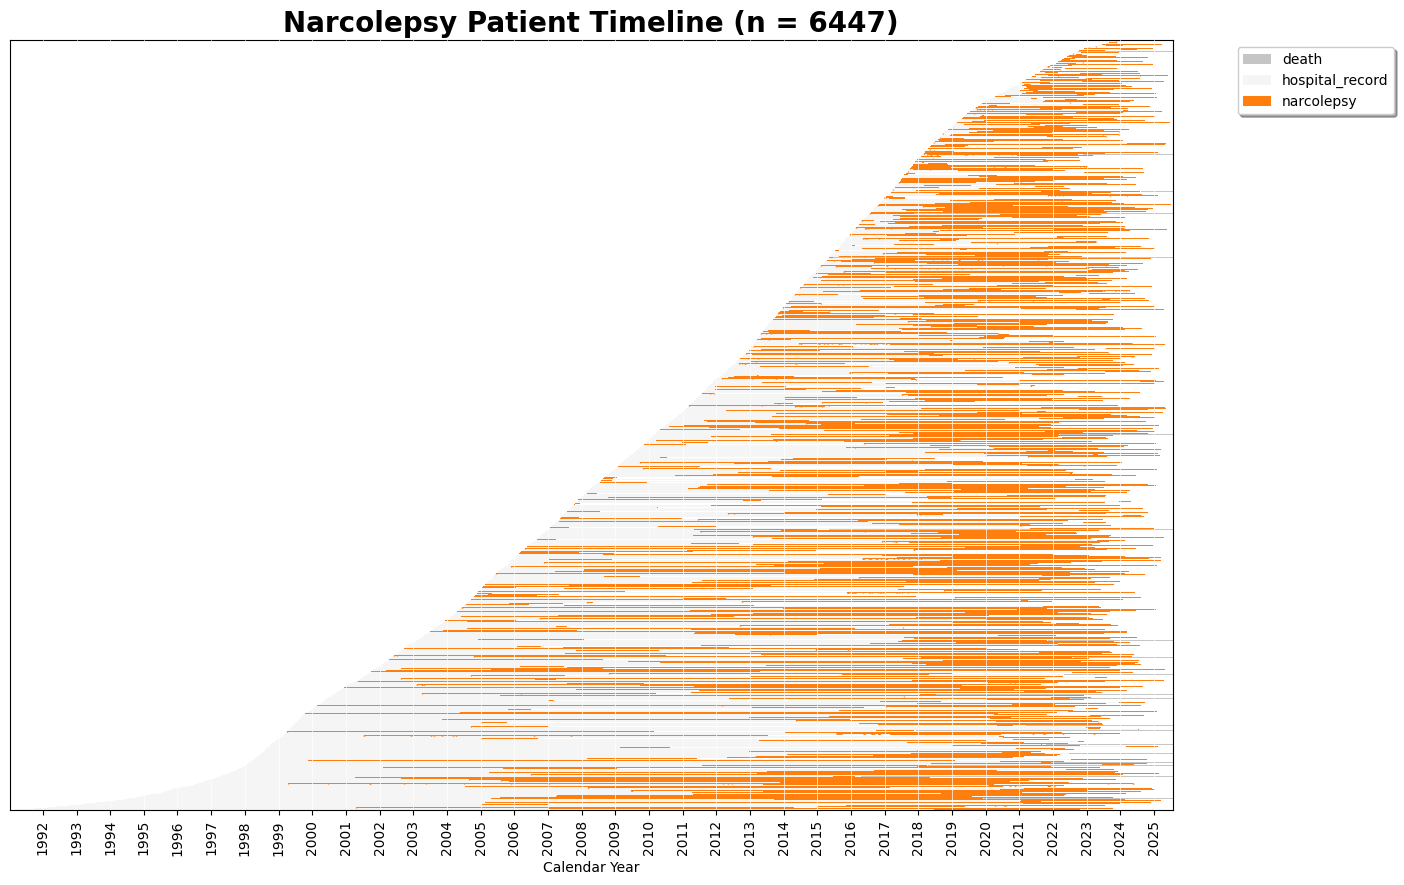

In [ ]:
fig = create_adaptive_timeline_plot_optimized(
    swimmer_df.filter(
        pl.col('start_date').dt.year() > 1990
    ),
    figsize=(15, 10),
    color_map={
        'narcolepsy': '#ff7f0e',
        'hospital_record': '#F5F5F5',           # Very light gray - background timeline,
        'death' : "#C5C5C5"
    },
    use_calendar_years=True,
    show_progress=True, 
    show_legend=True,
    legend_position='right',
)

fig.tick_params(axis='x', rotation=90)
n_patients = swimmer_df.n_unique('id')

fig.set_title(f"Narcolepsy Patient Timeline (n = {n_patients})", fontsize=20, fontweight='bold')